In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('1min_features_withFutures.csv')

In [3]:
data['date'] = pd.to_datetime(data['date'])
data = data[data['date'].dt.year == 2023]
data["computed_return"] = (data["nextVwap"] - data["vwap"]) / data["vwap"]

In [4]:
# Compute the number of rows corresponding to the first 10% of the data.
subset_rows = int(len(data) * 0.1)
data_subset = data.iloc[:subset_rows]

# Columns to exclude (if they exist in the DataFrame)
exclude_columns = [
    'DateTime', 'Stock', 'rtn', 'nextRtn', 'rtnMidQ', 
    'date', 'vwap', 'nextVwap', 'nextParkVol'
]

data_subset = data_subset.drop(columns=exclude_columns, errors='ignore')

data_subset = data_subset.select_dtypes(include=[np.number])


# Split into Features and Target
X = data_subset.drop(columns=["computed_return"])
y = data_subset["computed_return"]

# Fit the Random Forest Regressor
rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(X, y)


# Compute Feature Importances
feature_importances = rf_regressor.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importances based on Random Forest:")
print(importance_df)

Feature Importances based on Random Forest:
         Feature  Importance
2        prevRtn    0.126210
15   avgOrderImb    0.070533
11    avgNormBV5    0.070047
3     avgNormBV1    0.067785
1            SP1    0.063170
..           ...         ...
47    mfi_m_5min    0.001076
61  will_m_10min    0.001070
36   rsi_m_15min    0.000933
48   mfi_m_10min    0.000533
35   rsi_m_10min    0.000070

[71 rows x 2 columns]


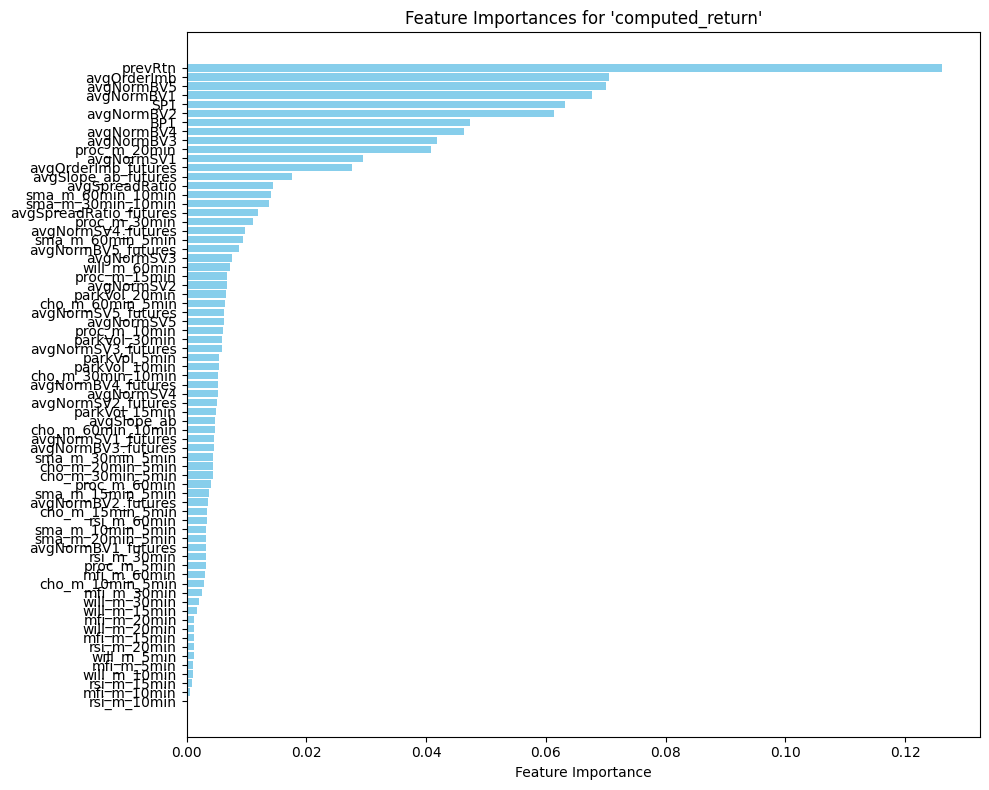

In [5]:
plt.figure(figsize=(10, 8))
importance_df_sorted = importance_df.sort_values(by="Importance", ascending=True)
plt.barh(importance_df_sorted['Feature'], importance_df_sorted['Importance'], color='skyblue')
plt.xlabel("Feature Importance")
plt.title("Feature Importances for 'computed_return'")
plt.tight_layout()
plt.show()

In [6]:
important_features = importance_df[importance_df['Importance'] > 0.005]

# Print the list of features and their importances
print("Features with importance greater than 0.005:")
print(len(important_features))
important_features


Features with importance greater than 0.005:
38


,Feature,Importance
2,prevRtn,0.126210
15,avgOrderImb,0.070533
11,avgNormBV5,0.070047
3,avgNormBV1,0.067785
1,SP1,0.063170
5,avgNormBV2,0.061359
0,BP1,0.047275
9,avgNormBV4,0.046355
7,avgNormBV3,0.041779
32,proc_m_20min,0.040822


In [7]:
important_features = importance_df[importance_df['Importance'] > 0.005]

# Extract the list of feature names
important_feature_list = important_features['Feature'].tolist()
print(important_feature_list)

['prevRtn', 'avgOrderImb', 'avgNormBV5', 'avgNormBV1', 'SP1', 'avgNormBV2', 'BP1', 'avgNormBV4', 'avgNormBV3', 'proc_m_20min', 'avgNormSV1', 'avgOrderImb_futures', 'avgSlope_ab_futures', 'avgSpreadRatio', 'sma_m_60min_10min', 'sma_m_30min_10min', 'avgSpreadRatio_futures', 'proc_m_30min', 'avgNormSV4_futures', 'sma_m_60min_5min', 'avgNormBV5_futures', 'avgNormSV3', 'will_m_60min', 'proc_m_15min', 'avgNormSV2', 'parkVol_20min', 'cho_m_60min_5min', 'avgNormSV5_futures', 'avgNormSV5', 'proc_m_10min', 'parkVol_30min', 'avgNormSV3_futures', 'parkVol_5min', 'parkVol_10min', 'cho_m_30min_10min', 'avgNormBV4_futures', 'avgNormSV4', 'avgNormSV2_futures']
